# Day 15 — 移动平均线（MA）

**目标**：从「会用均线」到「理解均线背后的逻辑」

- 🌅 上午：SMA vs EMA 原理 + 手算验证
- ☀️ 下午：多均线叠加图 + 金叉死叉信号
- 🌙 晚上：回测验证 MA 交叉策略的有效性

In [1]:
# ===== 基础设置 =====
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager
from matplotlib.gridspec import GridSpec

font_manager.fontManager.addfont('/System/Library/Fonts/Hiragino Sans GB.ttc')
plt.rcParams['font.family'] = 'Hiragino Sans GB'
plt.rcParams['axes.unicode_minus'] = False

print('✅ 环境就绪')

✅ 环境就绪


## 🌅 上午：SMA vs EMA

### SMA（简单移动平均）

$$\text{SMA}_5 = \frac{P_1 + P_2 + P_3 + P_4 + P_5}{5}$$

过去5天收盘价加起来÷5。每天权重一样，都是1/5。

### EMA（指数移动平均）

$$\text{EMA}_{\text{today}} = P_{\text{today}} \times k + \text{EMA}_{\text{yesterday}} \times (1-k)$$

其中 $k = \frac{2}{N+1}$，N是周期。**今天价格权重更大**，越旧的价权重越小。

> 一句话：SMA 对每天一视同仁，EMA 觉得今天比昨天重要。

In [3]:
# 加载茅台数据
df = pd.read_csv('../data/茅台.csv')
df['日期'] = pd.to_datetime(df['日期'])
df = df.set_index('日期').sort_index()

print(f'数据: {len(df)} 行, {df.index[0].date()} ~ {df.index[-1].date()}')
df[['开盘', '收盘', '最高', '最低', '成交量']].head()

数据: 250 行, 2025-07-01 ~ 2026-07-10


,开盘,收盘,最高,最低,成交量
日期,,,,,
2025-07-01,1357.02,1353.12,1359.96,1351.33,19878
2025-07-02,1357.52,1357.62,1362.82,1348.02,26218
2025-07-03,1360.02,1363.62,1370.71,1356.02,24413
2025-07-04,1363.72,1370.24,1379.91,1358.03,28767
2025-07-07,1370.30,1358.72,1371.52,1358.03,23855


In [4]:
# ===== 手算 SMA：验证 Pandas rolling 的逻辑 =====

# 取最近5天的收盘价，手动算一遍
last5 = df['收盘'].tail(5)
print("最近5天收盘价:")
print(last5)
print(f"\n手动加总÷5 = {last5.sum():.2f} ÷ 5 = {last5.mean():.2f}")
print(f"Pandas rolling(5).mean() 最后一天 = {df['收盘'].rolling(5).mean().iloc[-1]:.2f}")
print("\n→ 一样的！Pandas 的 rolling().mean() 就是手算的自动化。")

最近5天收盘价:
日期
2026-07-06    1206.91
2026-07-07    1188.80
2026-07-08    1199.30
2026-07-09    1182.19
2026-07-10    1204.98
Name: 收盘, dtype: float64

手动加总÷5 = 5982.18 ÷ 5 = 1196.44
Pandas rolling(5).mean() 最后一天 = 1196.44

→ 一样的！Pandas 的 rolling().mean() 就是手算的自动化。


findfont: Failed to find font weight normal, now using 300.
findfont: Failed to find font weight bold, now using 600.


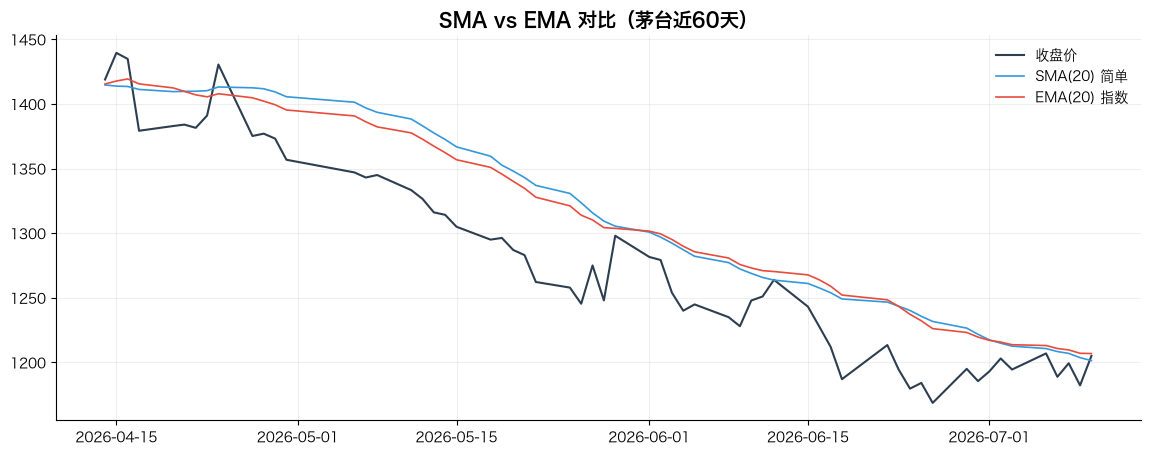

关键区别：EMA（红线）比 SMA（蓝线）更贴近价格——因为它对今天给更多权重。
涨的时候 EMA 在上面（反应快），跌的时候 EMA 在下面（反应也快）。


In [5]:
# ===== SMA vs EMA：同一个数据，两个角度 =====

# SMA：Pandas 自带
df['MA20_SMA'] = df['收盘'].rolling(20).mean()

# EMA：Pandas 自带 ewm(span=N) 就是 EMA
df['MA20_EMA'] = df['收盘'].ewm(span=20, adjust=False).mean()

# 画近60天对比
d = df.iloc[-60:]
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(d.index, d['收盘'], color='#2c3e50', lw=1.5, label='收盘价')
ax.plot(d.index, d['MA20_SMA'], color='#3498db', lw=1.2, label='SMA(20) 简单')
ax.plot(d.index, d['MA20_EMA'], color='#e74c3c', lw=1.2, label='EMA(20) 指数')
ax.set_title('SMA vs EMA 对比（茅台近60天）', fontsize=14, fontweight='bold')
ax.legend(frameon=False, fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.2)
plt.show()

print('关键区别：EMA（红线）比 SMA（蓝线）更贴近价格——因为它对今天给更多权重。')
print('涨的时候 EMA 在上面（反应快），跌的时候 EMA 在下面（反应也快）。')

## ☀️ 下午：金叉与死叉

- **金叉**：短期均线（快线）**从下方向上穿过**长期均线（慢线）→ 买入信号 🟢
- **死叉**：短期均线**从上方向下穿过**长期均线 → 卖出信号 🔴

直觉：短期线代表「最近情绪」，长期线代表「长期趋势」。
短期上穿长期 = 情绪变好突破趋势 → 看涨。
反过来 = 情绪恶化跌破趋势 → 看跌。

In [6]:
# ===== 计算均线 + 找金叉死叉 =====

df['MA5'] = df['收盘'].rolling(5).mean()
df['MA10'] = df['收盘'].rolling(10).mean()
df['MA20'] = df['收盘'].rolling(20).mean()
df['MA60'] = df['收盘'].rolling(60).mean()

# 金叉/死叉的判断：看 MA5 和 MA20 的相对位置
# MA5 > MA20 且前一天 MA5 <= MA20 → 刚金叉
# MA5 < MA20 且前一天 MA5 >= MA20 → 刚死叉

df['金叉'] = (df['MA5'] > df['MA20']) & (df['MA5'].shift(1) <= df['MA20'].shift(1))
df['死叉'] = (df['MA5'] < df['MA20']) & (df['MA5'].shift(1) >= df['MA20'].shift(1))

golden_dates = df[df['金叉']].index
death_dates = df[df['死叉']].index
print(f'近一年发现金叉 {len(golden_dates)} 次，死叉 {len(death_dates)} 次')
print(f'\n金叉日期: {[str(d.date()) for d in golden_dates]}')
print(f'死叉日期: {[str(d.date()) for d in death_dates]}')

近一年发现金叉 7 次，死叉 8 次

金叉日期: ['2025-08-21', '2025-10-20', '2025-11-12', '2025-12-22', '2026-02-03', '2026-03-18', '2026-04-01']
死叉日期: ['2025-08-01', '2025-09-22', '2025-10-29', '2025-11-27', '2026-01-15', '2026-03-03', '2026-03-25', '2026-04-21']


findfont: Failed to find font weight normal, now using 300.


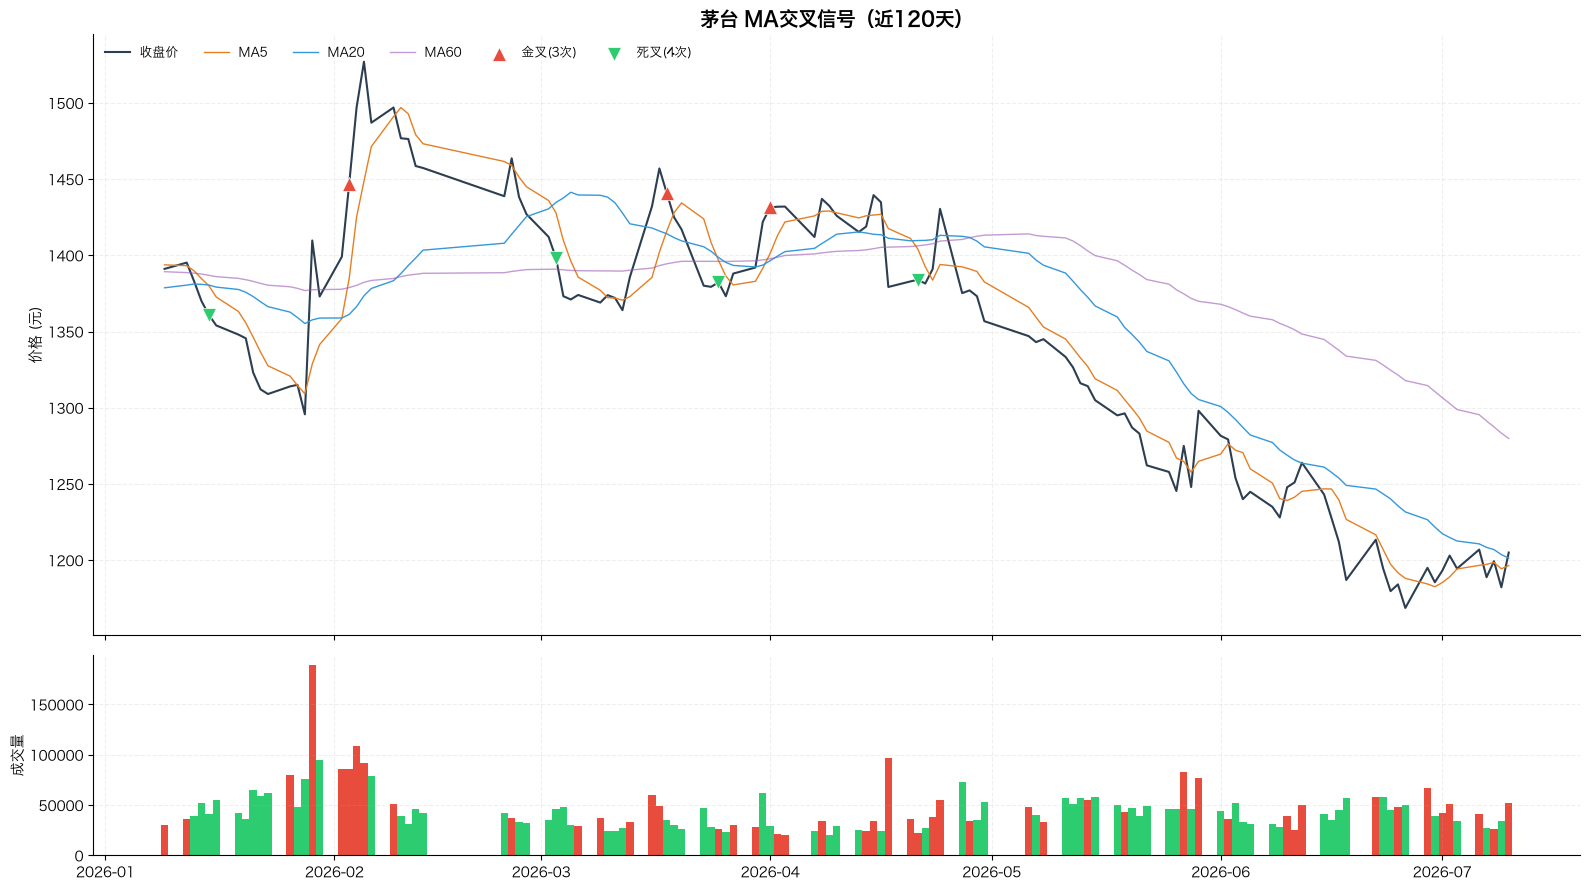

In [7]:
# ===== 画图：股价 + 均线 + 金叉死叉标记 =====

d = df.iloc[-120:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), 
                                gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# 上半：价格 + MA5/MA20/MA60
ax1.plot(d.index, d['收盘'], color='#2c3e50', lw=1.5, label='收盘价')
ax1.plot(d.index, d['MA5'], color='#e67e22', lw=1.0, label='MA5')
ax1.plot(d.index, d['MA20'], color='#3498db', lw=1.0, label='MA20')
ax1.plot(d.index, d['MA60'], color='#9b59b6', lw=1.0, alpha=0.6, label='MA60')

# 标金叉 🟢
golden = d[d['金叉']]
ax1.scatter(golden.index, golden['收盘'], color='#e74c3c', s=100, zorder=5,
            marker='^', edgecolor='white', lw=0.5, label=f'金叉({len(golden)}次)')

# 标死叉 🔴
death = d[d['死叉']]
ax1.scatter(death.index, death['收盘'], color='#2ecc71', s=100, zorder=5,
            marker='v', edgecolor='white', lw=0.5, label=f'死叉({len(death)}次)')

ax1.set_title('茅台 MA交叉信号（近120天）', fontsize=14, fontweight='bold')
ax1.legend(ncol=6, frameon=False, fontsize=9, loc='upper left')
ax1.set_ylabel('价格 (元)')

# 下半：成交量
up = d['收盘'] >= d['开盘']
ax2.bar(d.index[up], d['成交量'][up], color='#e74c3c', width=1.0)
ax2.bar(d.index[~up], d['成交量'][~up], color='#2ecc71', width=1.0)
ax2.set_ylabel('成交量')

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.2, ls='--')

plt.tight_layout()
plt.show()

## 🌙 晚上：回测验证——金叉后真的涨了吗？

拿了信号不能用眼睛判断，要用数据验证。
取每次金叉/死叉后的 N 天收益率，看胜率。

In [8]:
# ===== 回测：金叉/死叉后 N 天的涨跌情况 =====

def check_signal(df, signal_col, hold_days=5):
    """
    给定信号列（True的那天买入），持有 hold_days 天后卖出
    统计：涨几次、跌几次、平均收益
    """
    signal_dates = df[df[signal_col]].index
    results = []
    for date in signal_dates:
        pos = df.index.get_loc(date)
        if pos + hold_days >= len(df):
            continue
        buy_price = df['收盘'].iloc[pos]
        sell_price = df['收盘'].iloc[pos + hold_days]
        ret = (sell_price / buy_price - 1) * 100
        results.append({'信号日': date.strftime('%Y-%m-%d'), '买入价': buy_price, 
                       f'{hold_days}天后卖出价': sell_price, '收益率(%)': ret})
    return pd.DataFrame(results)

print('='*60)
print('金叉（买入信号）后持有5天的表现：')
print('='*60)
golden_result = check_signal(df, '金叉', hold_days=5)
if len(golden_result) > 0:
    print(golden_result.round(2).to_string(index=False))
    win = sum(golden_result['收益率(%)'] > 0)
    total = len(golden_result)
    print(f'\n📊 金叉后5天: 涨{win}次 / 跌{total-win}次 | 胜率 {win/total*100:.0f}% | 平均收益 {golden_result["收益率(%)"].mean():.2f}%')

print()
print('='*60)
print('死叉（卖出信号）后持有5天的表现：')
print('='*60)
death_result = check_signal(df, '死叉', hold_days=5)
if len(death_result) > 0:
    print(death_result.round(2).to_string(index=False))
    lose = sum(death_result['收益率(%)'] < 0)
    total = len(death_result)
    print(f'\n📊 死叉后5天: 涨{total-lose}次 / 跌{lose}次 | 下跌概率 {lose/total*100:.0f}% | 平均收益 {death_result["收益率(%)"].mean():.2f}%')


金叉（买入信号）后持有5天的表现：
       信号日     买入价  5天后卖出价  收益率(%)
2025-08-21 1396.27 1394.12   -0.15
2025-10-20 1405.95 1388.43   -1.25
2025-11-12 1413.17 1419.03    0.41
2025-12-22 1380.24 1373.98   -0.45
2026-02-03 1446.90 1476.78    2.07
2026-03-18 1440.78 1382.25   -4.06
2026-04-01 1431.42 1432.47    0.07

📊 金叉后5天: 涨3次 / 跌4次 | 胜率 43% | 平均收益 -0.48%

死叉（卖出信号）后持有5天的表现：
       信号日     买入价  5天后卖出价  收益率(%)
2025-08-01 1365.02 1368.99    0.29
2025-09-22 1401.37 1408.88    0.54
2025-10-29 1379.92 1368.10   -0.86
2025-11-27 1395.32 1372.00   -1.67
2026-01-15 1360.87 1312.04   -3.59
2026-03-03 1398.17 1373.86   -1.74
2026-03-25 1382.25 1431.42    3.56
2026-04-21 1383.99 1376.98   -0.51

📊 死叉后5天: 涨3次 / 跌5次 | 下跌概率 62% | 平均收益 -0.50%


findfont: Failed to find font weight bold, now using 600.


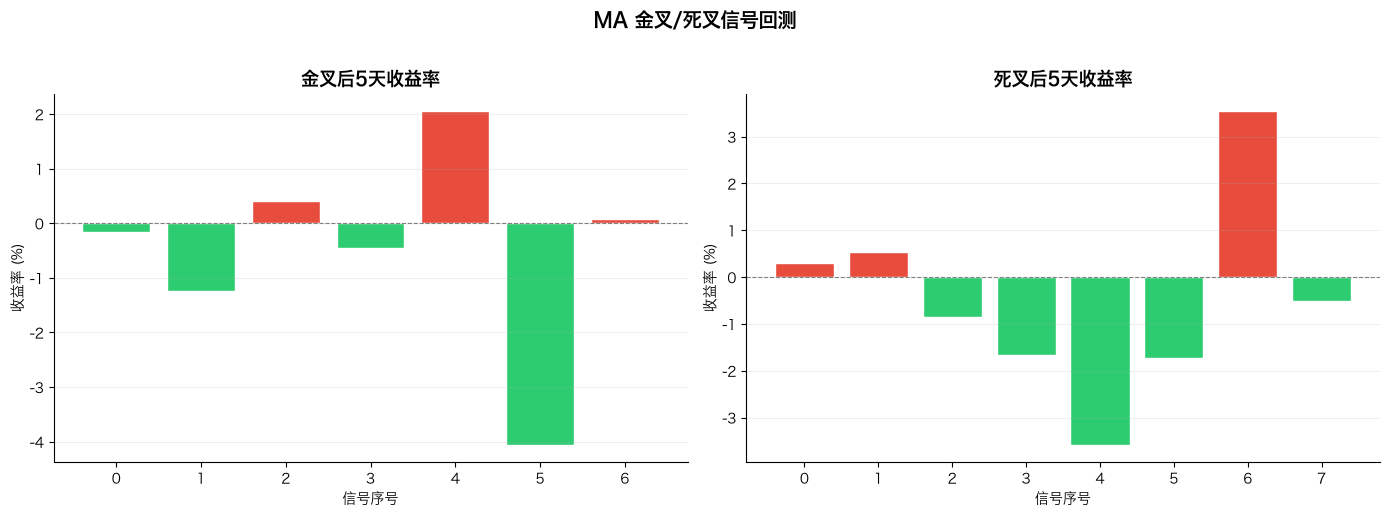

In [9]:
# ===== 可视化：金叉/死叉后的收益分布 =====

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

if len(golden_result) > 0:
    colors_g = ['#e74c3c' if r > 0 else '#2ecc71' for r in golden_result['收益率(%)']]
    ax1.bar(range(len(golden_result)), golden_result['收益率(%)'], color=colors_g, edgecolor='white')
    ax1.axhline(0, color='gray', lw=0.8, ls='--')
    ax1.set_title('金叉后5天收益率', fontsize=13, fontweight='bold')
    ax1.set_ylabel('收益率 (%)')
    ax1.set_xlabel('信号序号')

if len(death_result) > 0:
    # 死叉是看跌信号，所以跌了=信号生效（绿色），涨了=信号失效（红色）
    colors_d = ['#2ecc71' if r < 0 else '#e74c3c' for r in death_result['收益率(%)']]
    ax2.bar(range(len(death_result)), death_result['收益率(%)'], color=colors_d, edgecolor='white')
    ax2.axhline(0, color='gray', lw=0.8, ls='--')
    ax2.set_title('死叉后5天收益率', fontsize=13, fontweight='bold')
    ax2.set_ylabel('收益率 (%)')
    ax2.set_xlabel('信号序号')

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('MA 金叉/死叉信号回测', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 📝 今天的发现

运行完上面的回测后，回答这三个问题（写进 `day15/学习笔记.txt`）：

1. 金叉后5天，涨的多还是跌的多？胜率是多少？
2. 死叉后5天，跌的多还是涨的多？信号有效吗？
3. 如果只看 MA 交叉做买卖，能赚钱吗？为什么？